# **Bank Customer Churn Project**

This project develops a machine learning pipeline to predict customer churn in a bank's credit card portfolio. Using customer demographics, account activity, and transaction data, multiple classification models are evaluated to identify high-risk customers. The objective is not only to achieve strong predictive performance, but also to uncover actionable insights that can support customer retention strategies.

## **Data Overview**

In [55]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np

# scikit-learn (Data Preprosing)
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold

# Data Modeling Pipeline
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC

# Data Evaluation
from sklearn.model_selection import cross_validate
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

In [3]:
df = pd.read_csv('BankChurners.csv')

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (10127, 21)


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


The dataset contains approximately 10,000 customer records with 21 columns, including demographic information, account activity, and financial behavior.

The target variable is customer churn (Attrition_Flag), indicating whether a customer has left the bank’s credit card services.

After removing identifier fields (e.g., CLIENTNUM), 19 features are used for analysis and modeling.

The dataset includes both categorical and numerical variables, with no missing values but some entries labeled as "Unknown," which are treated as a separate category.

## **Data Cleaning and Wrangling**

### **1. Data Integrity Checks**

In [4]:
df.duplicated().sum()
df.duplicated(['CLIENTNUM']).sum()

np.int64(0)

No duplicate records or repeated customer IDs were found, confirming that each row represents a unique customer.

### **2. Data Type & Missing Values**

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10127 non-null  int64  
 1   Attrition_Flag            10127 non-null  object 
 2   Customer_Age              10127 non-null  int64  
 3   Gender                    10127 non-null  object 
 4   Dependent_count           10127 non-null  int64  
 5   Education_Level           10127 non-null  object 
 6   Marital_Status            10127 non-null  object 
 7   Income_Category           10127 non-null  object 
 8   Card_Category             10127 non-null  object 
 9   Months_on_book            10127 non-null  int64  
 10  Total_Relationship_Count  10127 non-null  int64  
 11  Months_Inactive_12_mon    10127 non-null  int64  
 12  Contacts_Count_12_mon     10127 non-null  int64  
 13  Credit_Limit              10127 non-null  float64
 14  Total_

The dataset contains a mix of numerical and categorical variables. No null values are present; however, some categorical features contain "Unknown" values.

### **3. Handling "Unknown" Values**

In [6]:
unknown_count = ((df['Education_Level'] == 'Unknown') |
                 (df['Marital_Status'] == 'Unknown') |
                 (df['Income_Category'] == 'Unknown')).sum()

print(f"{unknown_count} rows contain 'Unknown' values (~{unknown_count/len(df)*100:.1f}%).")


3046 rows contain 'Unknown' values (~30.1%).


A significant portion of the dataset (~30%) contains "Unknown" values across key categorical variables.

Instead of removing or imputing these values, they are retained as a separate category. This decision preserves potential signal in the data, as missingness itself may carry predictive information.

### **4. Numerical Data Validation**

In [8]:
num_cols = ['Customer_Age', 'Dependent_count', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']
df[num_cols].describe().T[['min', 'max']]

,min,max
Customer_Age,26.0,73.000
Dependent_count,0.0,5.000
Months_on_book,13.0,56.000
Total_Relationship_Count,1.0,6.000
Months_Inactive_12_mon,0.0,6.000
Contacts_Count_12_mon,0.0,6.000
Credit_Limit,1438.3,34516.000
Total_Revolving_Bal,0.0,2517.000
Avg_Open_To_Buy,3.0,34516.000
Total_Amt_Chng_Q4_Q1,0.0,3.397


All numerical variables fall within reasonable ranges, indicating no obvious data entry errors.

### **5. Outlier Analysis**

In [9]:
outlier_indices = set()

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    idx = df[(df[col] < lower) | (df[col] > upper)].index
    outlier_indices.update(idx)

print(f"{len(outlier_indices)} rows flagged as outliers (~{len(outlier_indices)/len(df)*100:.1f}%).")

3326 rows flagged as outliers (~32.8%).


A relatively large proportion of rows (~32%) were identified as statistical outliers.

These observations were retained, as removing them would significantly reduce the dataset size and may eliminate meaningful customer behavior patterns.

## **Exploratory Data Analysis**

### **1. Target Variable Distribution**

In [ ]:
plt.figure(figsize=(5,4))
sns.countplot(data=df, x='Attrition_Flag')
plt.title('Customer Churn Distribution')
plt.xticks(rotation=15)
plt.show()

The dataset is imbalanced, with significantly fewer attrited customers compared to existing customers.

This imbalance is important for modeling, as it can bias models toward predicting the majority class. Techniques such as SMOTE will be considered in later stages to address this issue.

### **2. Customer Behavior vs Churn**

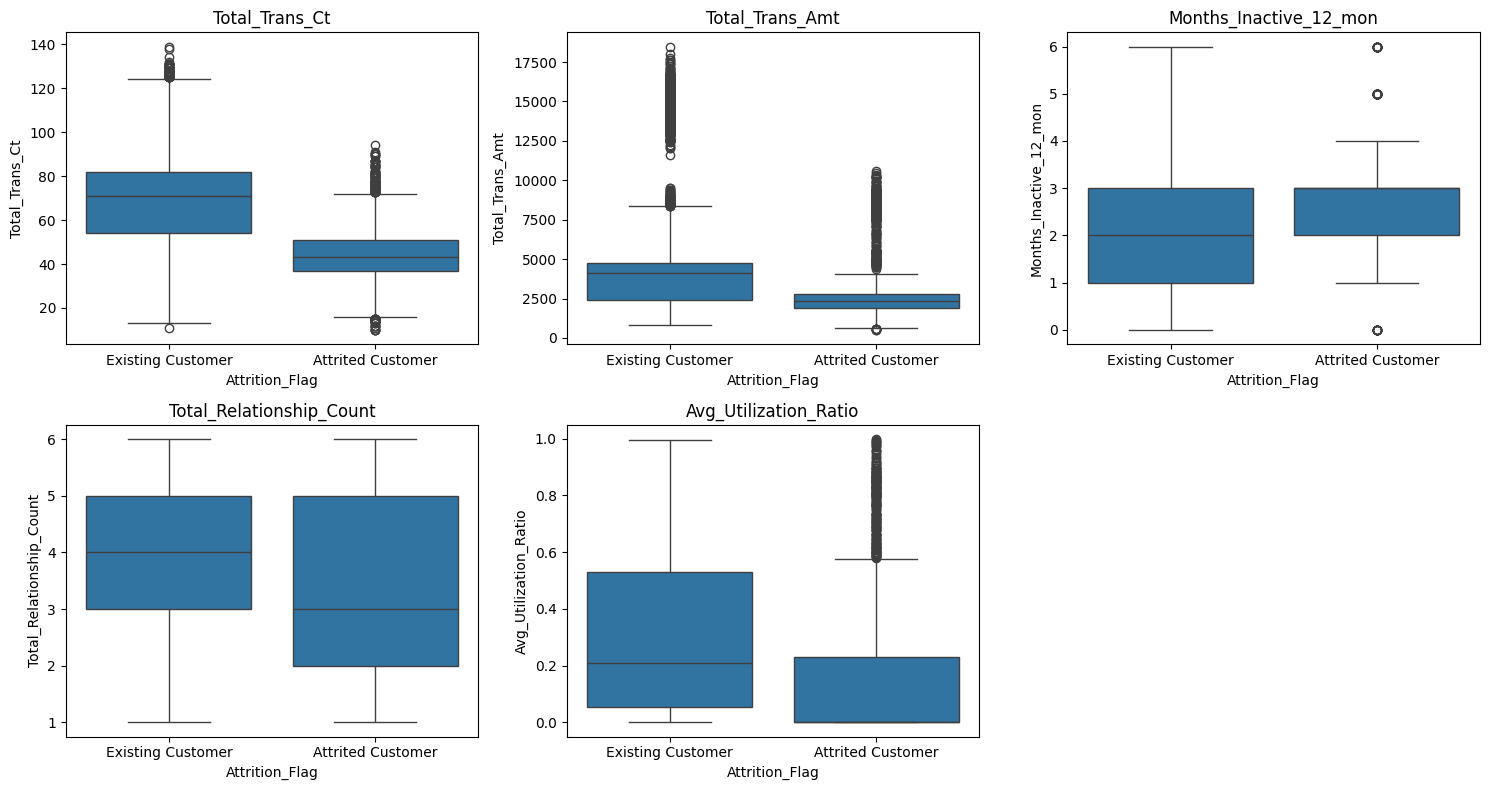

In [10]:
key_features = [
    'Total_Trans_Ct',
    'Total_Trans_Amt',
    'Months_Inactive_12_mon',
    'Total_Relationship_Count',
    'Avg_Utilization_Ratio'
]

plt.figure(figsize=(15,8))

for i, col in enumerate(key_features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=df, x='Attrition_Flag', y=col)
    plt.title(col)

plt.tight_layout()
plt.show()

Clear behavioral differences emerge between churned and retained customers:

- Attrited customers have significantly lower transaction counts and transaction amounts
- Higher inactivity levels are strongly associated with churn
- Customers who churn tend to have fewer relationships (products) with the bank
- Lower credit utilization is observed among churned customers

These patterns suggest that reduced engagement and declining transaction activity are strong indicators of churn.

### **3. Distribution Comparison**

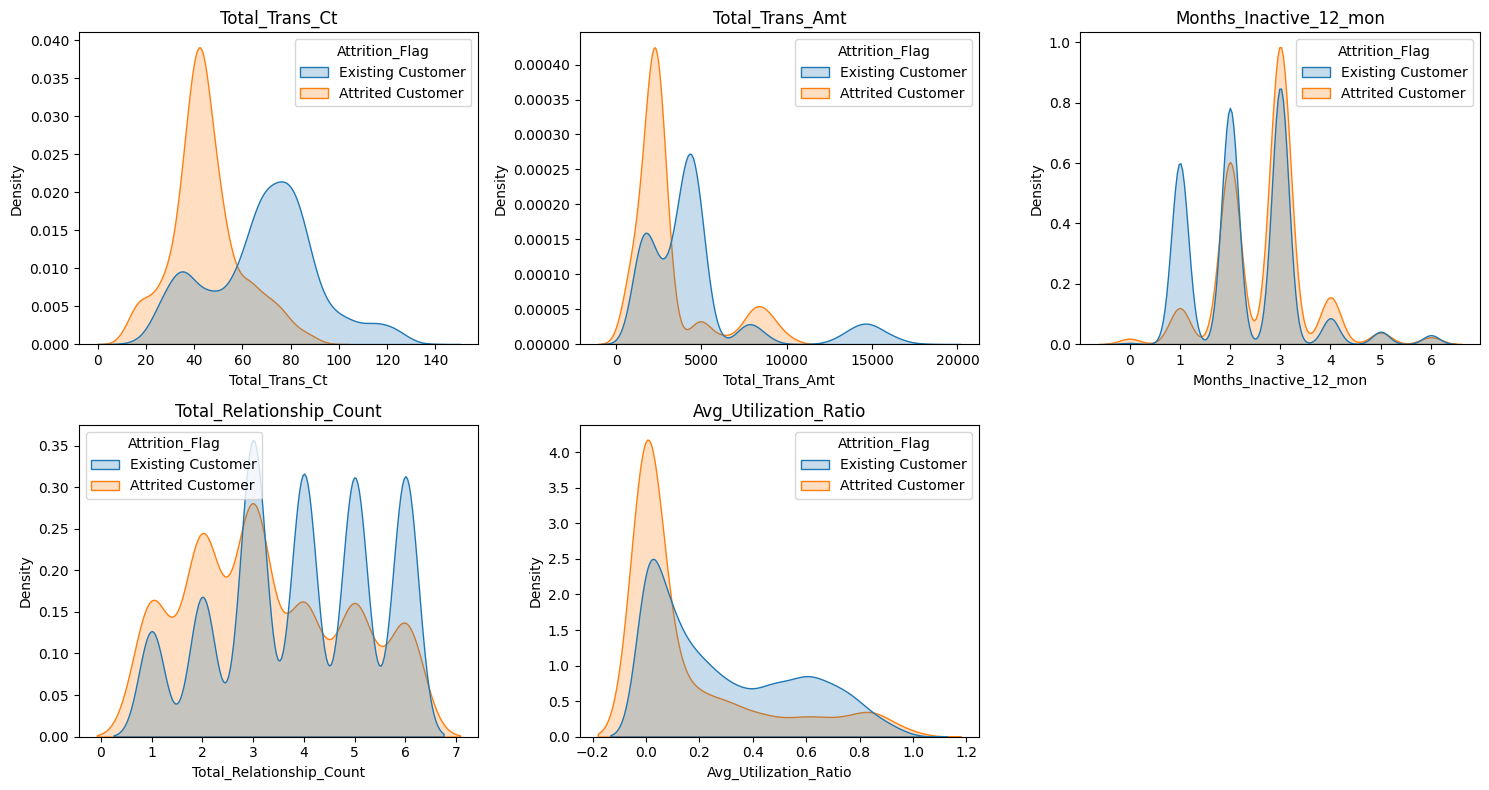

In [11]:
plt.figure(figsize=(15,8))

for i, col in enumerate(key_features, 1):
    plt.subplot(2, 3, i)
    sns.kdeplot(data=df, x=col, hue='Attrition_Flag', fill=True, common_norm=False)
    plt.title(col)

plt.tight_layout()
plt.show()

Distribution comparisons further highlight separation between churned and retained customers.

Notably, transaction-related features (transaction count and amount) show clear divergence between the two groups, reinforcing their predictive importance.

### **4. Categorical Impact**

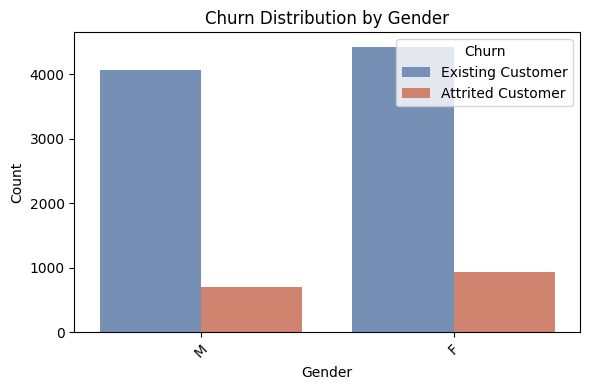

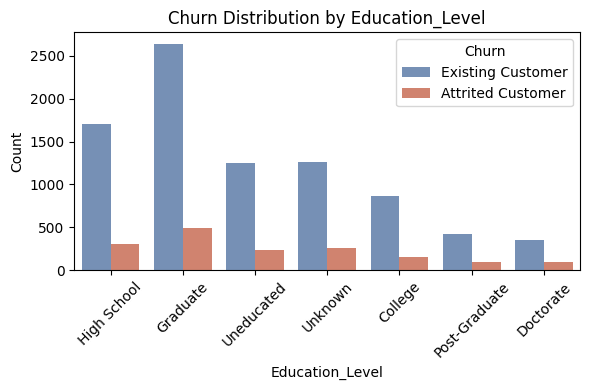

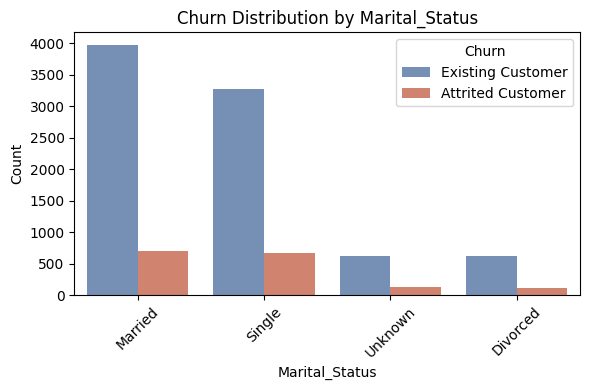

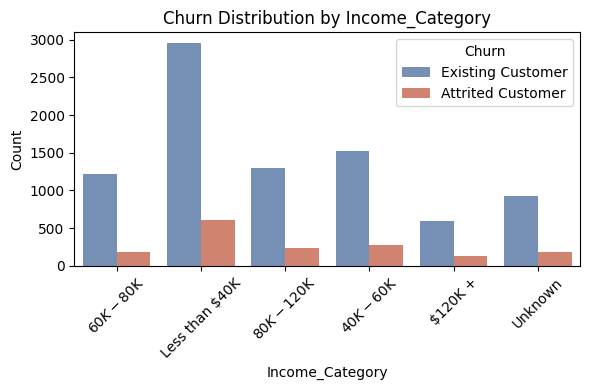

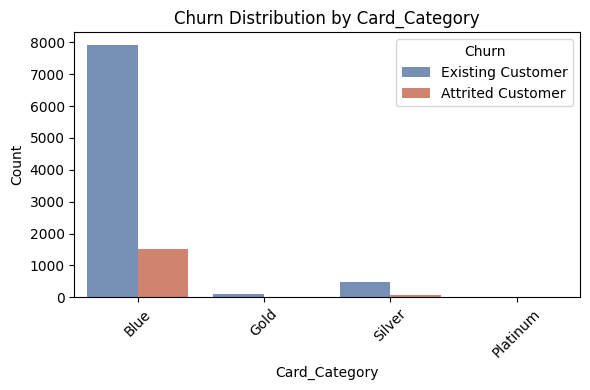

In [14]:
cat_cols = ['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']

# softer, professional colors
palette = ["#6C8EBF", "#E07A5F"]  # muted blue & coral

for col in cat_cols:
    plt.figure(figsize=(6,4))

    sns.countplot(
        data=df,
        x=col,
        hue='Attrition_Flag',
        palette=palette
    )

    plt.title(f'Churn Distribution by {col}', fontsize=12)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.legend(title='Churn')

    plt.tight_layout()
    plt.show()


Churn rates are relatively consistent across most categorical variables.

Slight variations are observed in certain categories (e.g., card type and education level), but categorical features appear less influential compared to behavioral and transactional variables.

### **5. Correlation Analysis**

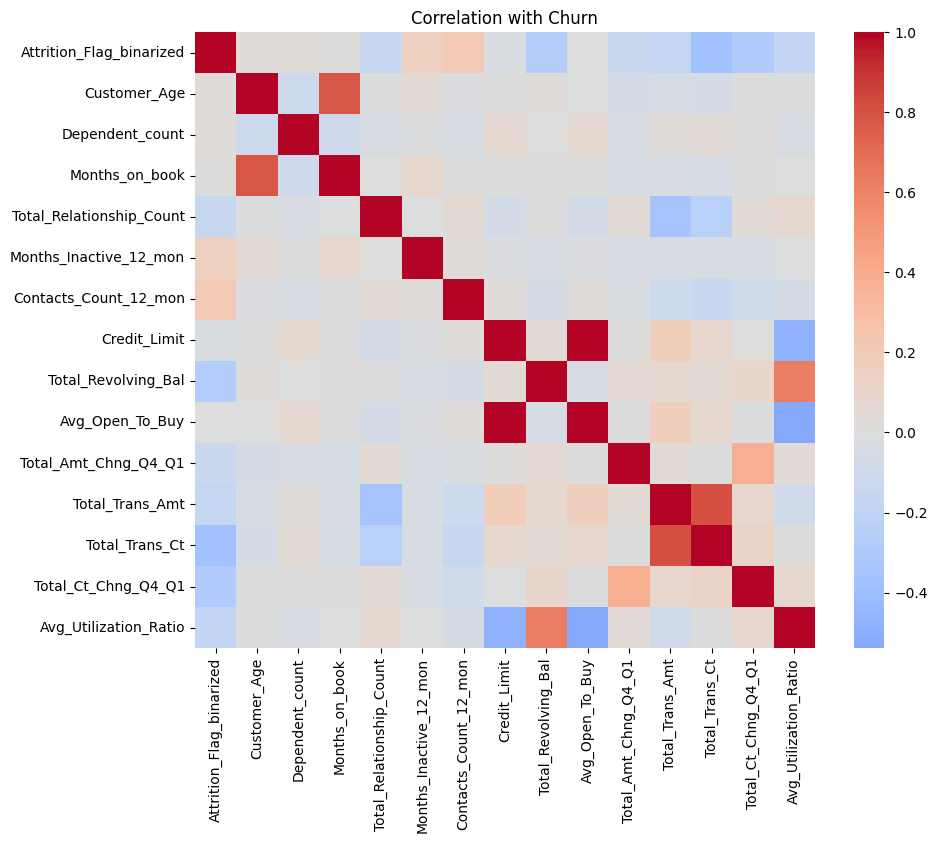

In [13]:
df['Attrition_Flag_binarized'] = df['Attrition_Flag'].map({
    'Existing Customer': 0,
    'Attrited Customer': 1
})

plt.figure(figsize=(10,8))
sns.heatmap(df[['Attrition_Flag_binarized'] + num_cols].corr(),
            cmap='coolwarm', center=0)
plt.title('Correlation with Churn')
plt.show()

Transaction count shows the strongest negative correlation with churn, followed by changes in transaction behavior and revolving balance.

While individual correlations are moderate, the combined effect of multiple features is expected to enhance predictive performance in machine learning models.

## **Data Preparation**

### **1. Feature / Target Split**

In [15]:
X = df.drop(columns=['Attrition_Flag', 'Attrition_Flag_binarized', 'CLIENTNUM'])
y = df['Attrition_Flag_binarized']

The dataset is split into features (X) and target (y), where the target represents customer churn.
Identifier columns such as CLIENTNUM are removed as they do not contribute to prediction.

### **2. Train-Test Split**

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

A stratified train-test split is used to preserve the class distribution of churn in both training and testing sets.

### **3. Preprocessing Pipeline**

In [20]:
cat_cols = ['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']
num_cols = [col for col in X.columns if col not in cat_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
    ]
)

Categorical variables are encoded using One-Hot Encoding, while numerical features are standardized where appropriate.

Preprocessing is handled using a ColumnTransformer to ensure transformations are applied consistently and without data leakage.

### **4. Cross-Validation**

In [21]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

Stratified K-Fold cross-validation is used to ensure robust model evaluation while maintaining class balance across folds.

## **ML Modeling**

Multiple classification models from different learning families were evaluated to compare performance and capture different patterns in the data. Models include Logistic Regression, CART Decision Tree, Random Forest, XGBoost, and SVM. These models were selected to compare linear, tree-based, and kernel-based approaches, capturing different patterns and levels of model complexity.

### **1. Model Pipeline**

#### **Logistic Regression**

In [22]:
lr_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression(max_iter=1000))
])

#### **CART Decision Tree**

In [23]:
dt_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', DecisionTreeClassifier(random_state=42))
])

#### **Random Forest**

In [24]:
rf_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(random_state=42))
])

#### **XGBoost**

In [25]:
xgb_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', XGBClassifier(
        eval_metric='logloss',
        random_state=42
    ))
])

#### **Support Vector Machine**

In [26]:
svm_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', SVC())
])

### **2. Model Dictionary**

In [30]:
models = {
    "Logistic Regression": lr_pipeline,
    "Decision Tree": dt_pipeline,
    "Random Forest": rf_pipeline,
    "XGBoost": xgb_pipeline,
    "SVM": svm_pipeline
}

### **3. Modeling Strategy**

Each model is implemented using a consistent pipeline that includes preprocessing, class imbalance handling (SMOTE), and model training.

This ensures that all transformations are applied correctly within cross-validation, preventing data leakage and enabling fair comparison across models.

## **Model Evaluation**

### **1. Training Set Evaluation**

In [31]:
scoring = {
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1'
}

cv_results = {}

for name, model in models.items():
    results = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=False
    )

    cv_results[name] = {
        metric: results[f'test_{metric}'].mean()
        for metric in scoring
    }

cv_df = pd.DataFrame(cv_results).T.round(3)
cv_df

,precision,recall,f1
Logistic Regression,0.531,0.843,0.652
Decision Tree,0.747,0.810,0.777
Random Forest,0.880,0.835,0.856
XGBoost,0.914,0.896,0.905
SVM,0.730,0.862,0.790


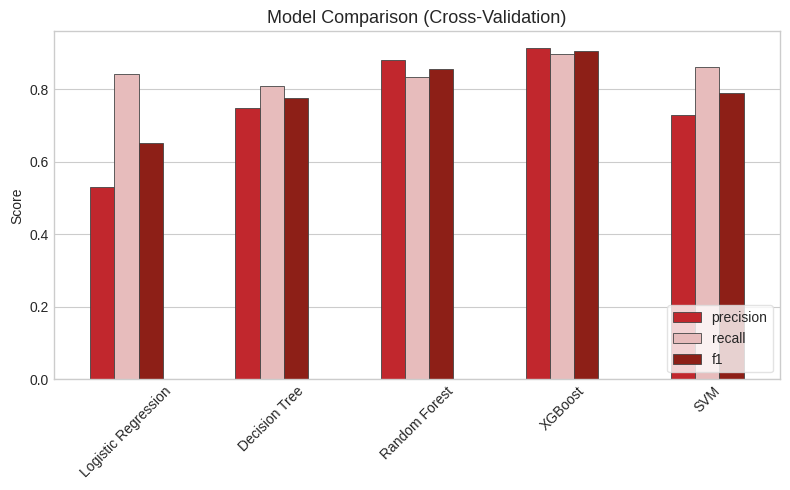

In [59]:
plt.style.use('seaborn-v0_8-whitegrid')

colors = ["#c1272d","#e7bcbc", "#8d1f17"]

ax = cv_df.plot(
    kind='bar',
    figsize=(8,5),
    color=colors,
    edgecolor='#444444',
    linewidth=0.6
)

ax.xaxis.grid(False) # Remove vertical grid lines

plt.title("Model Comparison (Cross-Validation)", fontsize=13)
plt.ylabel("Score")
plt.xticks(rotation=45)

plt.legend(
    loc='lower right',
    frameon=True,
    facecolor='white',
    edgecolor='#DDDDDD'
)

plt.tight_layout()
plt.show()

XGBoost consistently outperforms other models across precision, recall, and F1-score.

Tree-based ensemble methods (Random Forest and XGBoost) generally perform better than linear and distance-based models, indicating the presence of nonlinear relationships in the data.

### **2. Test Set Evaluation**

In [45]:
best_model = models['XGBoost']
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

In [46]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1701
           1       0.92      0.87      0.89       325

    accuracy                           0.97      2026
   macro avg       0.95      0.93      0.94      2026
weighted avg       0.97      0.97      0.97      2026



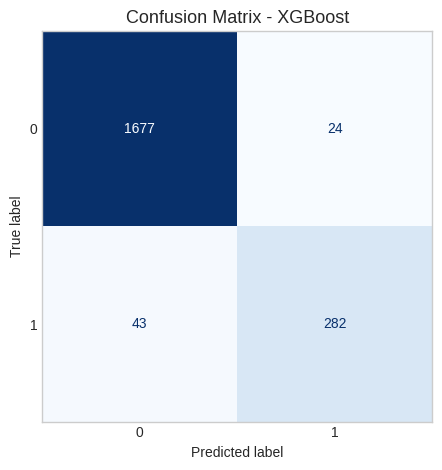

In [54]:
disp = ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    cmap="Blues",          # soft, clean color
    colorbar=False         # removes side bar (cleaner look)
)

disp.ax_.set_title("Confusion Matrix - XGBoost", fontsize=13)
disp.ax_.grid(False)

plt.tight_layout()
plt.show()

The XGBoost model demonstrates strong performance on the test set, maintaining a good balance between precision and recall.

The confusion matrix shows that the model is effective at identifying churned customers while minimizing false negatives, which is critical in a churn prediction context.

XGBoost was selected as the final model due to its superior performance across all evaluation metrics and its ability to capture complex nonlinear relationships.

Additionally, the small performance gap between cross-validation and test results indicates good generalization, suggesting the model is not overfitting.

### **Feature Importance**

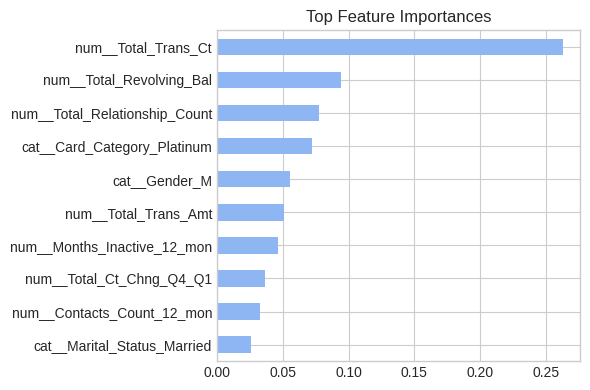

In [57]:
model = best_model.named_steps['model']

importances = model.feature_importances_
features = best_model.named_steps['preprocessing'].get_feature_names_out()

feat_imp = pd.Series(importances, index=features)\
            .sort_values(ascending=False)[:10]

feat_imp.plot(kind='barh', figsize=(6,4), color="#8DB6F2")
plt.title("Top Feature Importances")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

The model identifies transaction activity and customer engagement features as the strongest predictors of churn.

In particular, variables such as total transaction count, transaction amount, and inactivity metrics play a significant role, reinforcing patterns observed during exploratory analysis.

This alignment between EDA findings and model behavior increases confidence in the model’s reliability and interpretability.

This suggests that monitoring declines in transaction activity could serve as an early warning system for customer churn.

## **Conclusion**

This project demonstrates the application of machine learning techniques to predict customer churn using behavioral and financial data.

Key patterns observed during analysis indicate that customer inactivity, lower transaction volume, and reduced engagement are strong indicators of churn. These insights suggest that changes in customer behavior are more predictive than static demographic features.

Among the models evaluated, XGBoost achieved the best overall performance, effectively capturing nonlinear relationships and maintaining strong generalization on unseen data.

From a business perspective, this model can support proactive customer retention strategies by identifying at-risk customers early. Financial institutions could leverage these predictions to trigger targeted interventions such as personalized offers or engagement campaigns.

Future improvements could include hyperparameter tuning, feature engineering, and deployment of the model into a real-time monitoring system.